# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay,accuracy_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# DATA LOADING & CLEANING


In [ ]:

df = pd.read_csv("/content/health_care.csv")


In [ ]:
df.head()

,patient_name,age,blood_pressure,cholesterol,diabetes,heart_rate,temperature,gender,bmi,smoker,...,kidney_function,mental_health_score,infection_risk,diagnosis,treatment_outcome,treatment_start,treatment_end,adherence_level,hospital_stay_days,medication
0,Fatma Hassan,54,140.0,166.0,0,74,36.7,Female,31.2,0,...,75,1,Low,Liver Disease,failure,5/22/2023,7/2/2023,Medium,8,NaN
1,Hana Mostafa,84,116.0,234.0,0,88,38.0,Female,31.5,0,...,69,10,High,Healthy,improvement,5/22/2023,7/2/2023,Medium,2,No Drug
2,Fatma Hassan,74,147.0,265.0,0,76,37.7,Female,32.1,0,...,89,6,Medium,Kidney Disease,failure,9/20/2023,12/20/2024,Medium,22,Lisinopril
3,Yassin Mahmoud,80,125.0,262.0,0,90,36.2,Female,31.9,1,...,85,1,Low,Heart Disease,failure,3/24/2024,4/2/2024,Low,28,Lisinopril
4,Laila Hassan,74,133.0,153.0,0,84,37.3,Male,37.5,0,...,72,3,Low,Liver Disease,failure,12/6/2024,3/13/2025,Medium,29,Statins


In [ ]:
df.shape

(5000, 25)

In [ ]:
df.columns

Index(['patient_name', 'age', 'blood_pressure', 'cholesterol', 'diabetes',
       'heart_rate', 'temperature', 'gender', 'bmi', 'smoker',
       'exercise_per_week', 'alcohol_intake', 'hospital_visits', 'blood_sugar',
       'liver_function', 'kidney_function', 'mental_health_score',
       'infection_risk', 'diagnosis', 'treatment_outcome', 'treatment_start',
       'treatment_end', 'adherence_level', 'hospital_stay_days', 'medication'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_name         5000 non-null   object 
 1   age                  5000 non-null   int64  
 2   blood_pressure       4750 non-null   float64
 3   cholesterol          4650 non-null   float64
 4   diabetes             5000 non-null   int64  
 5   heart_rate           5000 non-null   int64  
 6   temperature          5000 non-null   float64
 7   gender               5000 non-null   object 
 8   bmi                  4700 non-null   float64
 9   smoker               5000 non-null   int64  
 10  exercise_per_week    5000 non-null   int64  
 11  alcohol_intake       2521 non-null   object 
 12  hospital_visits      5000 non-null   int64  
 13  blood_sugar          5000 non-null   float64
 14  liver_function       5000 non-null   float64
 15  kidney_function      5000 non-null   i

In [ ]:
df.describe()

,age,blood_pressure,cholesterol,diabetes,heart_rate,temperature,bmi,smoker,exercise_per_week,hospital_visits,blood_sugar,liver_function,kidney_function,mental_health_score,hospital_stay_days
count,5000.000000,4750.000000,4650.000000,5000.000000,5000.000000,5000.00000,4700.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54.828200,129.740421,209.394194,0.206400,79.403400,37.26418,28.012128,0.302600,3.12980,4.623800,129.848020,49.247760,74.153800,5.088400,12.234000
std,20.376264,15.078059,29.164240,0.404761,9.660255,0.72445,5.107462,0.459429,2.13529,3.266926,31.730374,21.675851,19.630232,2.425647,9.350355
min,20.000000,90.000000,150.000000,0.000000,60.000000,36.00000,18.500000,0.000000,0.00000,0.000000,80.000000,10.000000,30.000000,1.000000,0.000000
25%,37.000000,119.000000,188.000000,0.000000,73.000000,36.60000,24.300000,0.000000,1.00000,2.000000,104.450000,32.000000,60.000000,3.000000,4.000000
50%,54.000000,130.000000,209.000000,0.000000,79.000000,37.30000,27.900000,0.000000,3.00000,4.000000,124.700000,49.250000,74.000000,5.000000,10.000000
75%,73.000000,140.000000,230.000000,0.000000,86.000000,37.90000,31.500000,1.000000,5.00000,8.000000,152.325000,66.900000,88.000000,7.000000,20.000000
max,90.000000,180.000000,300.000000,1.000000,117.000000,38.50000,40.000000,1.000000,7.00000,10.000000,199.800000,100.000000,120.000000,10.000000,30.000000


In [ ]:
df.isnull().sum()

,0
patient_name,0
age,0
blood_pressure,250
cholesterol,350
diabetes,0
heart_rate,0
temperature,0
gender,0
bmi,300
smoker,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
patient_name,object
age,int64
blood_pressure,float64
cholesterol,float64
diabetes,int64
heart_rate,int64
temperature,float64
gender,object
bmi,float64
smoker,int64


In [ ]:
df["gender"].value_counts()


,count
gender,
Female,2543
Male,2457


In [ ]:
df["diagnosis"].value_counts()

,count
diagnosis,
Healthy,1746
Diabetes,1032
Kidney Disease,785
Hypertension,721
Liver Disease,640
Heart Disease,76


In [ ]:
df["treatment_outcome"].value_counts()

,count
treatment_outcome,
failure,3348
improvement,1243
recovered,409


In [ ]:
# Fill missing numeric values with Median
df['blood_pressure'] = df['blood_pressure'].fillna(df['blood_pressure'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Fill missing categorical value with 'None'
df['alcohol_intake'] = df['alcohol_intake'].fillna('None')

# Fill missing medication values with the Most Frequent value (Mode)
df['medication'] = df['medication'].fillna(df['medication'].mode()[0])

# Calculate missing treatment start dates using (treatment_end - hospital_stay_days)
df['treatment_end'] = pd.to_datetime(df['treatment_end'])
df['treatment_start'] = df['treatment_start'].fillna(df['treatment_end'] - pd.to_timedelta(df['hospital_stay_days'], unit='D'))


In [ ]:
df.isnull().sum()

,0
patient_name,0
age,0
blood_pressure,0
cholesterol,0
diabetes,0
heart_rate,0
temperature,0
gender,0
bmi,0
smoker,0


In [ ]:
print(df.dtypes)
print("\nObject/string columns:")
print(df.select_dtypes(include='object').columns.tolist())

age                                 int64
blood_pressure                    float64
cholesterol                       float64
diabetes                            int64
heart_rate                          int64
temperature                       float64
gender                             object
bmi                               float64
smoker                              int64
exercise_per_week                   int64
alcohol_intake                     object
hospital_visits                     int64
blood_sugar                       float64
liver_function                    float64
kidney_function                     int64
mental_health_score                 int64
infection_risk                     object
treatment_outcome                  object
treatment_start            datetime64[ns]
treatment_end              datetime64[ns]
adherence_level                    object
hospital_stay_days                  int64
medication                         object
treatment_duration_days           

In [ ]:
# drop unnecessary colmns
# df = df.drop(columns=['patient_name','diagnosis'])

In [ ]:
df['treatment_start'] = pd.to_datetime(df['treatment_start'])
df['treatment_end'] = pd.to_datetime(df['treatment_end'])
df['treatment_duration_days'] = (df['treatment_end'] - df['treatment_start']).dt.days

df = df.drop(columns=['treatment_start', 'treatment_end'])

In [ ]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [ ]:
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}

df['infection_risk'] = df['infection_risk'].map(ordinal_map)
df['adherence_level'] = df['adherence_level'].map(ordinal_map)

# alcohol_intake has missing values too — map first, keep NaN as NaN for now
df['alcohol_intake'] = df['alcohol_intake'].map(ordinal_map)

# Boxplots for outliers

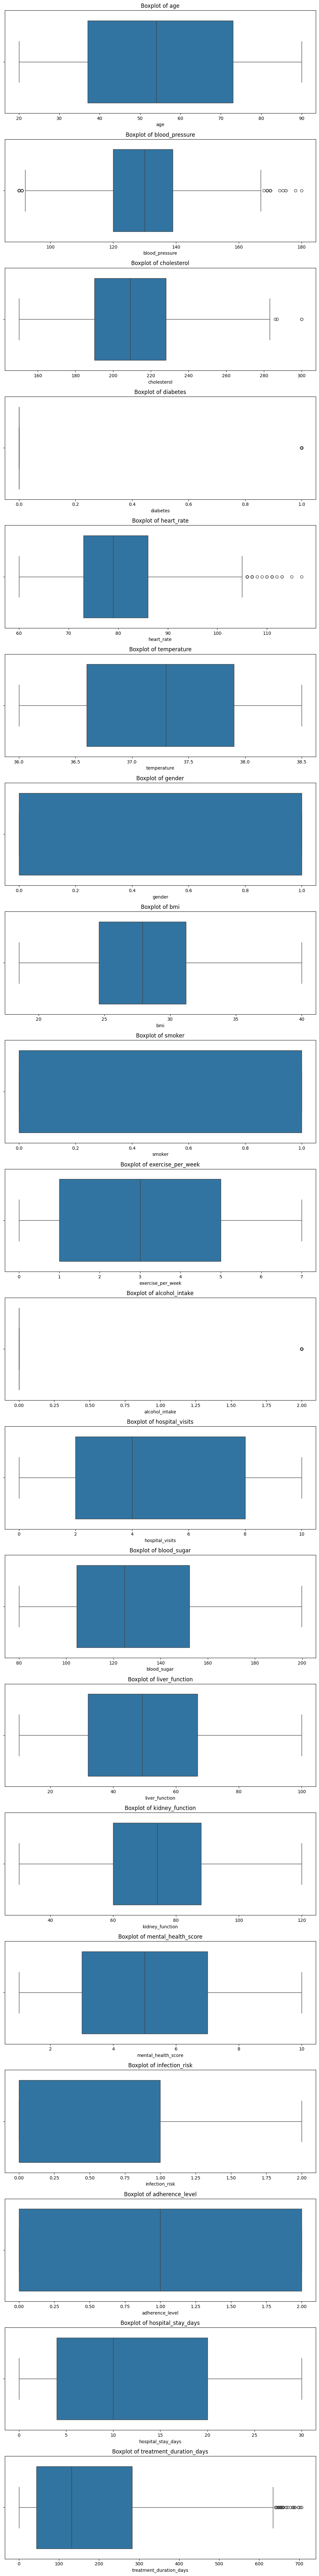

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(10, len(numeric_cols)*4))

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

# Patient age discription

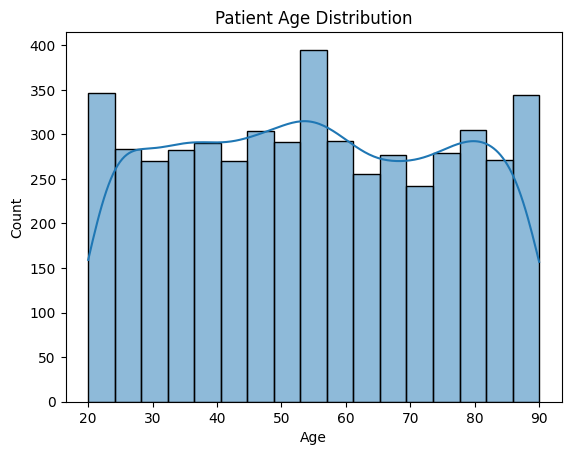

In [ ]:
# Visualize age distribution across patients
sns.histplot(df['age'], kde=True)
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Gender plot

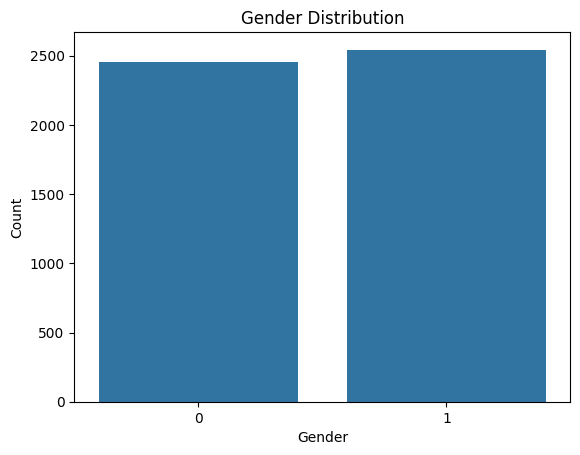

In [ ]:
# Count plot for patient genders
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Heatmap for all data

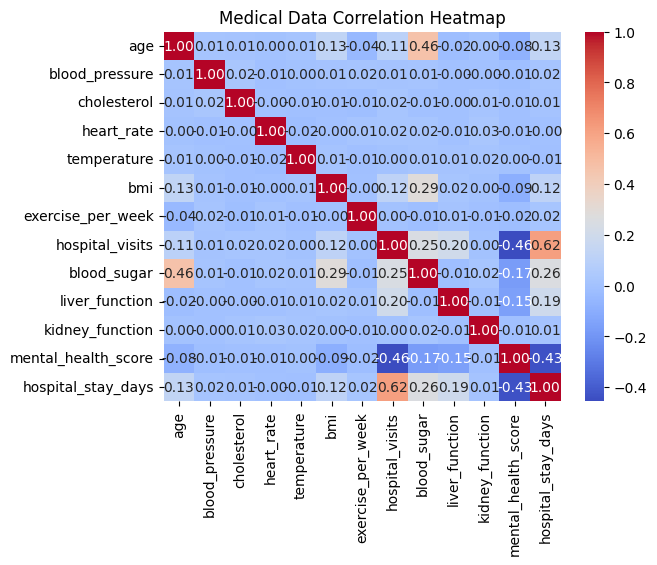

In [ ]:
# Select the numerical columns for correlation analysis
numeric_cols = [
    "age",
    "blood_pressure",
    "cholesterol",
    "heart_rate",
    "temperature",
    "bmi",
    "exercise_per_week",
    "hospital_visits",
    "blood_sugar",
    "liver_function",
    "kidney_function",
    "mental_health_score",
    "hospital_stay_days"
]

# Calculate the correlation matrix
correlation = df[numeric_cols].corr()

# Create the heatmap
sns.heatmap(
    correlation,
    annot=True,       # Display correlation values inside the cells
    cmap="coolwarm", # Color scheme
    fmt=".2f"        # Show values with 2 decimal places
)

# Add a title
plt.title("Medical Data Correlation Heatmap")

# Display the heatmap
plt.show()

# Insight:
# Hospital visits show the strongest positive correlation with hospital stay days (0.62),
# while mental health score shows a moderate negative correlation (-0.43).
# Most other medical variables have weak or negligible correlations with hospital stay.

# The effect of age

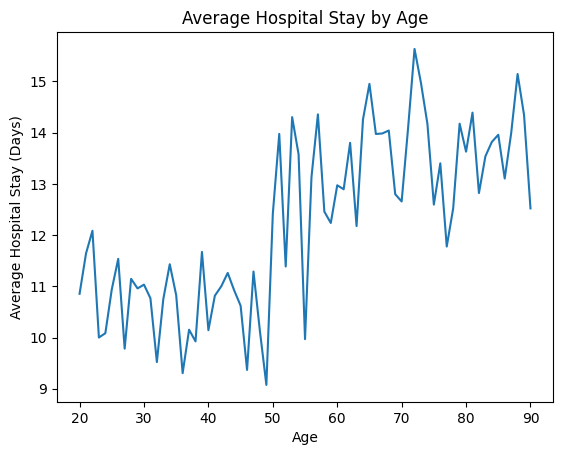

In [ ]:
age_stay = df.groupby("age")["hospital_stay_days"].mean()

age_stay.plot(kind="line")

plt.title("Average Hospital Stay by Age")
plt.xlabel("Age")
plt.ylabel("Average Hospital Stay (Days)")
plt.show()

# The effect of bmi & blood sugar

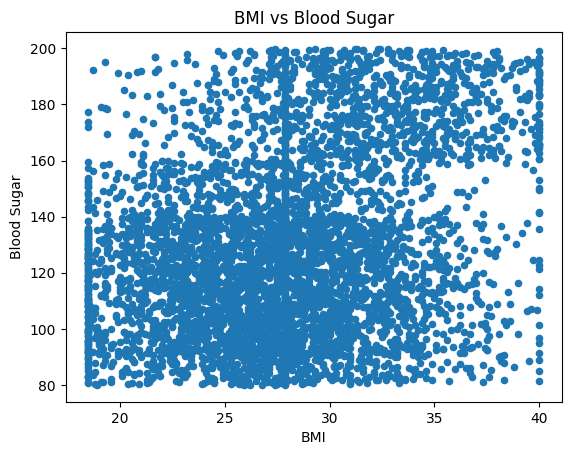

In [ ]:
df.plot(
    x="bmi",
    y="blood_sugar",
    kind="scatter"
)

plt.title("BMI vs Blood Sugar")
plt.xlabel("BMI")
plt.ylabel("Blood Sugar")
plt.show()

# Diagnosis Distribution

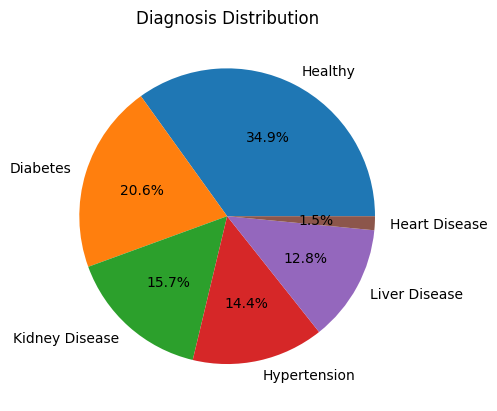

In [ ]:
df["diagnosis"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Diagnosis Distribution")
plt.ylabel("")
plt.show()

# Outcome by Medication

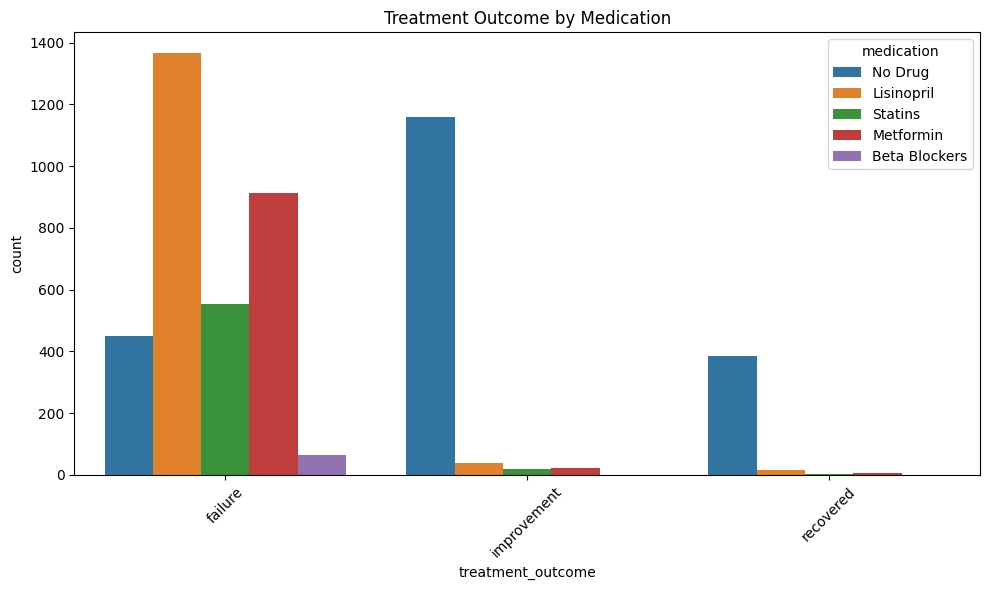

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='treatment_outcome', hue='medication')
plt.title("Treatment Outcome by Medication")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Dividing feautures

In [ ]:

X = df.drop(columns=['treatment_outcome'])
y = df['treatment_outcome']

# encoding

In [ ]:

# 1. Drop identifiers / leakage columns
X = X.drop(columns=['patient_name', 'diagnosis'], errors='ignore')

# 2. Engineer duration from dates, drop raw dates
X['treatment_start'] = pd.to_datetime(X['treatment_start'])
X['treatment_end'] = pd.to_datetime(X['treatment_end'])
X['treatment_duration_days'] = (X['treatment_end'] - X['treatment_start']).dt.days
X = X.drop(columns=['treatment_start', 'treatment_end'])

# 3. Binary encode gender
X['gender'] = X['gender'].str.strip().str.title()
X['gender'] = X['gender'].map({'Male': 0, 'Female': 1})

# 4. Ordinal encode
ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
X['infection_risk'] = X['infection_risk'].map(ordinal_map)
X['adherence_level'] = X['adherence_level'].map(ordinal_map)
X['alcohol_intake'] = X['alcohol_intake'].replace('None', np.nan).map(ordinal_map)

# 5. One-hot encode medication
X = pd.get_dummies(X, columns=['medication'], drop_first=True)

# 6. Impute remaining numeric NaNs
num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

print("Object columns remaining:", X.select_dtypes(include='object').columns.tolist())
print("Missing values remaining:", X.isnull().sum().sum())

Object columns remaining: []
Missing values remaining: 0


# splitting data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # preserves the failure/improvement/recovered ratio
    random_state=42
)

print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train class distribution:
 treatment_outcome
failure        0.66975
improvement    0.24850
recovered      0.08175
Name: proportion, dtype: float64

Test class distribution:
 treatment_outcome
failure        0.669
improvement    0.249
recovered      0.082
Name: proportion, dtype: float64


# logisitic regression

In [ ]:
log_reg= LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=42

)

# confusin matrix

In [ ]:
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.941
Macro F1: 0.8893231511981282

Classification report:
               precision    recall  f1-score   support

     failure       1.00      0.97      0.98       669
 improvement       0.90      0.88      0.89       249
   recovered       0.70      0.93      0.80        82

    accuracy                           0.94      1000
   macro avg       0.87      0.92      0.89      1000
weighted avg       0.95      0.94      0.94      1000


Confusion matrix:
 [[647  19   3]
 [  2 218  29]
 [  0   6  76]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


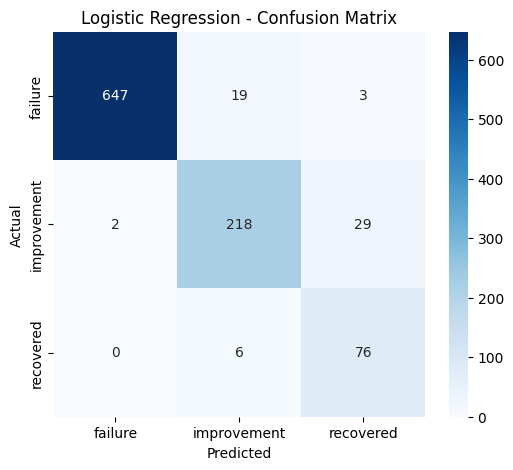

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=log_reg.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# model accuracy

In [ ]:
results = {}
results['Logistic Regression'] = accuracy_score(y_test, y_pred)
print(results)

{'Logistic Regression': 0.941}


# KNN

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled = scaler.transform(X_test)          # transform test with same scaler

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5,     # you can tune this later
    weights='distance'  # closer neighbors count more — helps a bit with imbalance
)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# confusin matrix

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Macro F1:", f1_score(y_test, y_pred_knn, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_knn))


Accuracy: 0.917
Macro F1: 0.802403192623339

Classification report:
               precision    recall  f1-score   support

     failure       0.98      0.97      0.97       669
 improvement       0.78      0.95      0.86       249
   recovered       0.90      0.43      0.58        82

    accuracy                           0.92      1000
   macro avg       0.89      0.78      0.80      1000
weighted avg       0.92      0.92      0.91      1000


Confusion matrix:
 [[646  23   0]
 [  9 236   4]
 [  3  44  35]]


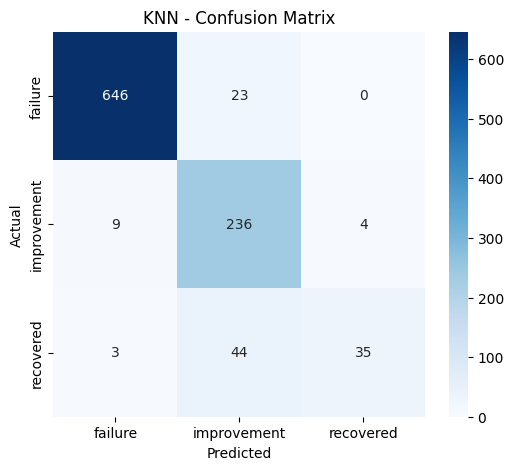

In [ ]:
labels_order = sorted(y_test.unique())
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=labels_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN - Confusion Matrix')
plt.show()

# accuracy

In [ ]:
results['KNN'] = accuracy_score(y_test, y_pred_knn)
print(results)

{'Logistic Regression': 0.941, 'KNN': 0.917}


# XGBoost Model

# encoding

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'failure': np.int64(0), 'improvement': np.int64(1), 'recovered': np.int64(2)}


In [ ]:

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    random_state=42
)

xgb_model.fit(X_train, y_train_enc, sample_weight=sample_weights)
y_pred_xgb_enc = xgb_model.predict(X_test)

# decoding

In [ ]:
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Macro F1:", f1_score(y_test, y_pred_xgb, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))



Accuracy: 0.999
Macro F1: 0.9990803671919494

Classification report:
               precision    recall  f1-score   support

     failure       1.00      1.00      1.00       669
 improvement       1.00      1.00      1.00       249
   recovered       1.00      1.00      1.00        82

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion matrix:
 [[669   0   0]
 [  1 248   0]
 [  0   0  82]]


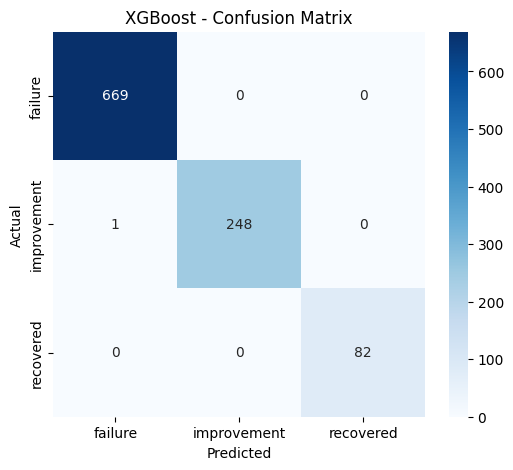

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost - Confusion Matrix')
plt.show()

# accuracy

In [ ]:
results['XGBoost'] = accuracy_score(y_test, y_pred_xgb)

print(results)

{'Logistic Regression': 0.941, 'KNN': 0.917, 'XGBoost': 0.999}


In [ ]:
svm_model = SVC(
    kernel = 'rbf',
    C=1.0,
    gamma = 'scale'
)


Accuracy: 0.86
Macro F1: 0.57442766999081

Classification report:
               precision    recall  f1-score   support

     failure       0.96      0.95      0.95       669
 improvement       0.67      0.91      0.77       249
   recovered       0.00      0.00      0.00        82

    accuracy                           0.86      1000
   macro avg       0.54      0.62      0.57      1000
weighted avg       0.81      0.86      0.83      1000


Confusion matrix:
 [[634  35   0]
 [ 23 226   0]
 [  6  76   0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


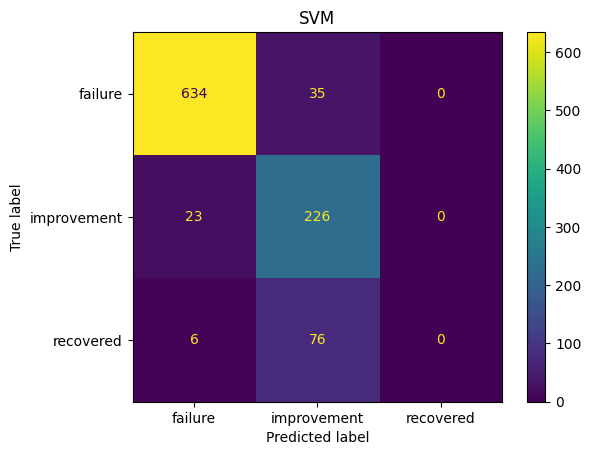

In [ ]:
svm_model.fit(X_train,y_train)
y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_svm))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.title("SVM")
plt.show()

In [ ]:
results['SVM'] = accuracy_score(y_test, y_pred_svm)
print(results)

{'Logistic Regression': 0.941, 'KNN': 0.917, 'XGBoost': 0.999, 'SVM': 0.86}


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

Random Forest Accuracy: 0.998

Classification Report:
              precision    recall  f1-score   support

     failure       1.00      1.00      1.00       669
 improvement       1.00      1.00      1.00       249
   recovered       1.00      1.00      1.00        82

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



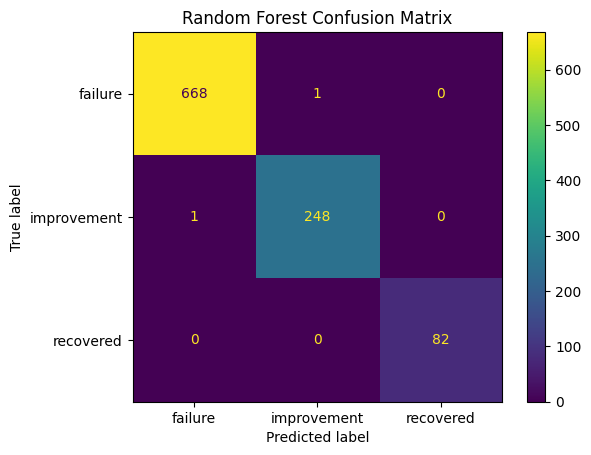

In [ ]:
# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")
plt.show()

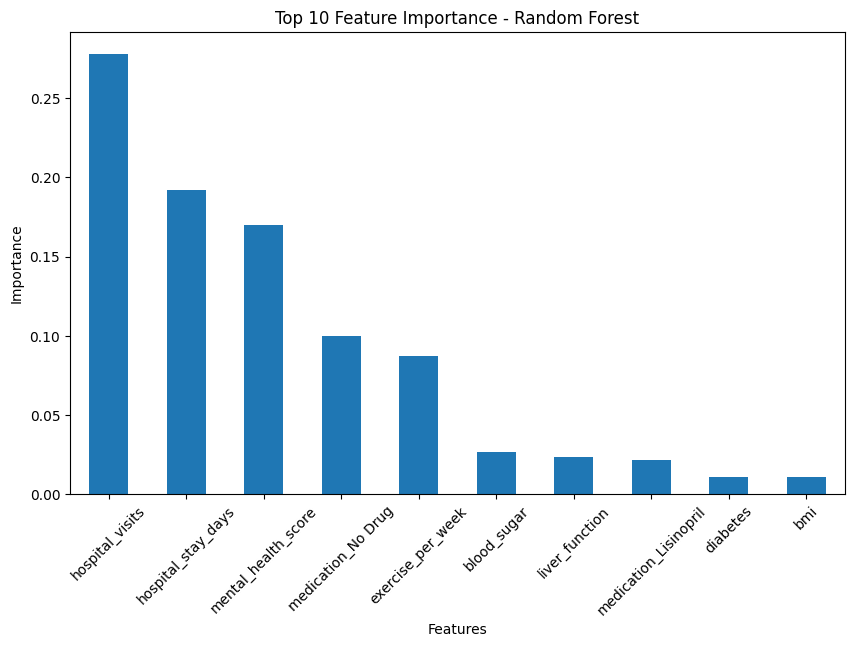

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

feature_importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
results['RandomForest'] = accuracy_score(y_test, y_pred_rf)
print(results)

{'Logistic Regression': 0.941, 'KNN': 0.917, 'XGBoost': 0.999, 'SVM': 0.86, 'RandomForest': 0.998}


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.971
Macro F1: 0.9496335205107637

Classification report:
               precision    recall  f1-score   support

     failure       1.00      0.98      0.99       669
 improvement       0.93      0.96      0.94       249
   recovered       0.89      0.95      0.92        82

    accuracy                           0.97      1000
   macro avg       0.94      0.96      0.95      1000
weighted avg       0.97      0.97      0.97      1000



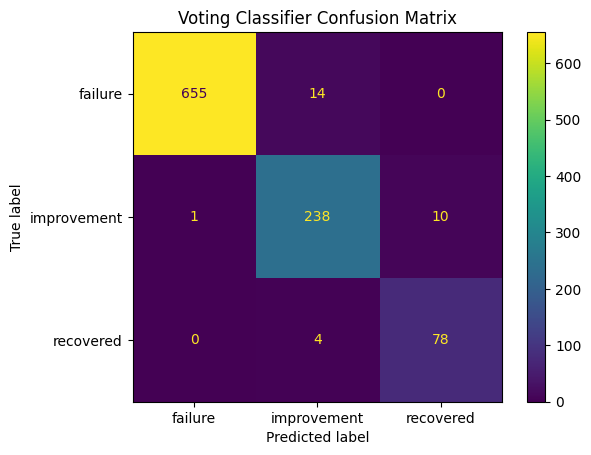

In [ ]:
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(multi_class='multinomial', class_weight='balanced', max_iter=1000, random_state=42))
])

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

voting_model = VotingClassifier(
    estimators=[
        ('lr', log_reg_pipe),
        ('svm', svm_pipe),
        ('rf', rf_model)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_voting))
print("Macro F1:", f1_score(y_test, y_pred_voting, average='macro'))
print("\nClassification report:\n", classification_report(y_test, y_pred_voting))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_voting)
plt.title("Voting Classifier Confusion Matrix")
plt.show()

# comparsion between models

In [ ]:
results['RandomForest'] = accuracy_score(y_test, y_pred_voting)
print(results)

{'Logistic Regression': 0.941, 'KNN': 0.917, 'XGBoost': 0.999, 'SVM': 0.86, 'RandomForest': 0.971}


In [ ]:

model_predictions = {
    'Logistic Regression': y_pred,
    'KNN': y_pred_knn,
    'XGBoost': y_pred_xgb,
    'SVM':y_pred_svm,
    'Random Forest' :y_pred_rf,
    'Voting Classifier' : y_pred_voting
}

comparison_data = []

for name, preds in model_predictions.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Macro F1': f1_score(y_test, preds, average='macro'),
        'Macro Precision': precision_score(y_test, preds, average='macro'),
        'Macro Recall': recall_score(y_test, preds, average='macro')
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
comparison_df = comparison_df.round(3)
print(comparison_df)

                     Accuracy  Macro F1  Macro Precision  Macro Recall
Model                                                                 
Logistic Regression     0.941     0.889            0.866         0.923
KNN                     0.917     0.802            0.886         0.780
XGBoost                 0.999     0.999            1.000         0.999
SVM                     0.860     0.574            0.542         0.618
Random Forest           0.998     0.998            0.998         0.998
Voting Classifier       0.971     0.950            0.938         0.962


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


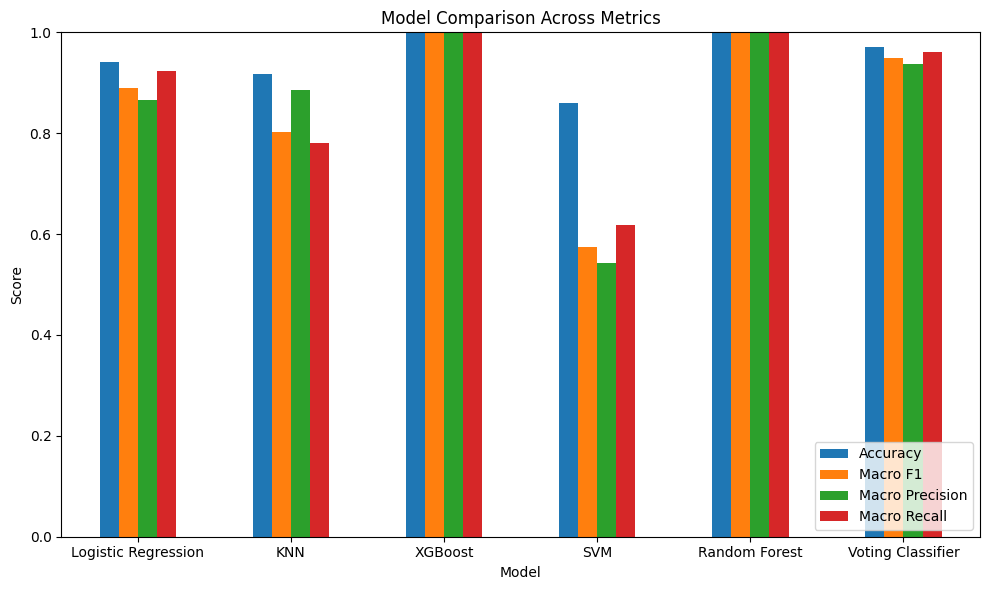

In [ ]:
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

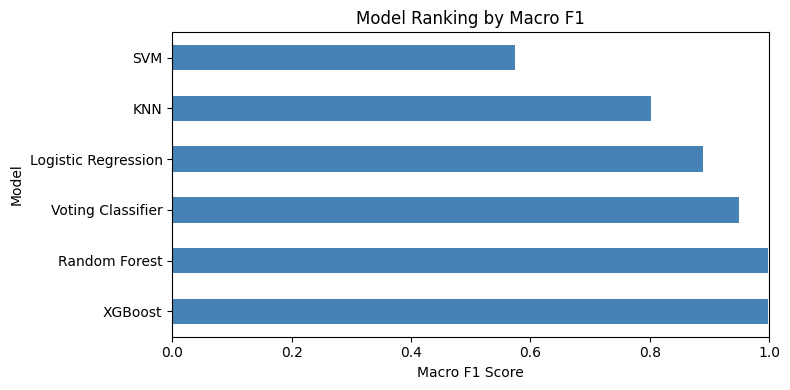

In [ ]:
comparison_df['Macro F1'].sort_values(ascending=False).plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.xlabel('Macro F1 Score')
plt.title('Model Ranking by Macro F1')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()